# 05 その場足踏み（S3）

## 背景

04 までは 4 脚接地のまま高さを変えた。この段の新しい現象は **周期ゲイトで足を上げること** である（[S3](../docs/block-curriculum/02_Stage_Ladder.md)）。予測最適化も着地点の先送りもまだ無い。\(v^{ref}=0\)。

立脚は 02/04 と同じ \(\tau=h-J^{\top}F\)。\(F_z\) は立脚本 \(n_s\) で割る EqualShare に、04 の高さ P を足してよい。遊脚は \(F=0\) なので MapJT だけでは落ちる。空中軌道を直交 PD で追う。

着地点の水平は **離地時の xy のまま**。前進は次の番号である。

### 成功条件（数値。ここが合否）

[README §3.8](../docs/block-curriculum/00_README.md)。**連続 5.0 秒以上、全ステップ。** 一瞬の接地や「数歩」は不合格。符号を逆にして足が上がらない静止も不合格である。

\(T=7.0\,\mathrm{s}\)。\(xy_0,z_0\) は走行開始時。

| 量 | 条件 |
|---|---|
| \(\lvert\mathrm{roll}\rvert,\lvert\mathrm{pitch}\rvert\) | \(<0.35\,\mathrm{rad}\)、連続 \(\ge 5.0\,\mathrm{s}\) |
| \(\lVert xy-xy_0\rVert\) | \(<0.30\,\mathrm{m}\) |
| ベース \(z\) | \(>0.20\,\mathrm{m}\) |
| `qpos` | 有限 |
| 各脚の実測空中（`contact_on=0`） | \(\ge 0.15\,\mathrm{s}\)（指令どおり足が床を離れる） |
| 対角ペア指令 | FL+RR のみ、FR+RL のみ、の両方が出現 |
| 結果 | GIF 1 本以上。指令 GRF（白）と実接触。失敗走行の GIF は消さない |

トロット offset は上流 PyMPC と同じ \([0.5,1.0,1.0,0.5]\)（FL, FR, RL, RR）。周波数・duty は EqualShare が 2 脚支持で倒れない範囲で選ぶ。満たすまで 06 へ進まない。

## 目的

- ゲイト \(c_i=[\phi_i<d]\) で立脚だけが体重を持つ
- 遊脚は SwingPath（sine \(z\)）+ \(\tau=J^{\top}(K_p e+K_d e_v)\)
- 符号や \(h\) の足し方を間違えると、足が上がらないか転倒することを失敗ログで残す

## 数式

$$
\phi_i\leftarrow(\phi_i+\Delta t\,f)\bmod 1,\qquad c_i=[\phi_i<d],\qquad n_s=\sum_i c_i
$$

$$
F_{z,i}=\begin{cases}(mg+k_p(z_0-z)-k_d\dot z)/n_s & c_i=1\\ 0 & c_i=0\end{cases},\qquad F_{x,i}=F_{y,i}=0
$$

立脚:

$$
\tau_i=h_i-J_i^{\top}F_i
$$

遊脚（離地位置 \(p^{\mathrm{lift}}\)、正規化時間 \(s\in[0,1]\)）:

$$
p^{des}=p^{\mathrm{lift}}+(0,0,h_{\mathrm{step}}\sin(\pi s)),\qquad
\tau_i=J_i^{\top}\bigl(K_p(p^{des}-p)+K_d(v^{des}-v)\bigr)
$$

仮想仕事の符号は立脚の \(-J^{\top}F\)（床から足への力）と、遊脚の \(+J^{\top}F_{ee}\)（足を目標へ加速する力）で逆である。

## 図

```
phi, duty --> c
c=1: HeightPdShare / ns --> h - J^T F
c=0: SwingPath(xy=lift-off) --> + J^T (Kp e + Kd ev)
                 \--> clip --> plant
```

## 思考過程

2 脚の対角支持は静力学的に細い。duty を高くして overlap を残し、遊脚時間を短くする。\(h\) を遊脚に足すと脚が伸びたままになり、接触が切れない。逆符号 \( -J^{\top}F_{ee}\) も同様に「立ったまま」になる。

## 仮説

1. 遊脚を \(h\) だけ（直交 PD なし）にすると、足は軌道を追わず転ぶ
2. \(\tau=-J^{\top}F_{ee}\) だと空中時間がほぼ 0 で、5 秒立っても足踏みではない
3. \(+J^{\top}\) でも \(h\) 付き・高ゲインだと足が飛びすぎて倒れる
4. \(+J^{\top}\)、遊脚に \(h\) を足さない、duty \(0.96\)、\(k_p^{sw}=300\) なら接触が切れ、かつ 5 秒持つ


In [1]:
# --- このセルの意図 ---
# S3: 周期ゲイトで立脚だけ EqualShare+高さP、遊脚は直交 PD。制御は Notebook に書く。

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))  # 内容: plant / GIF だけ src。制御式は下に書く
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

# --- 背景の成功条件 ---
HOLD_S = 5.0       # 内容: 連続 True の最長が 5秒以上
ATT_TOL = 0.35     # 内容: |roll|,|pitch| [rad]。足踏みなので 02 の 0.10 より緩い
XY_TOL = 0.30      # 内容: その場。水平ドリフト上限 [m]
Z_MIN = 0.20       # 内容: ベースが沈みすぎない [m]
AIR_S = 0.15       # 内容: 各脚の実測空中時間 [s]。接触が切れないと不合格
T_RUN = 7.0        # 内容: 5秒判定のあとにも余白を残す
FREQ = 1.0         # 内容: 歩数周波数 [Hz]
DUTY_OK = 0.96     # 内容: overlap を長くし、2脚支持を短くする
STEP_H = 0.02      # 内容: 遊脚の目標上げ幅 [m]
KP_SW, KD_SW = 300.0, 20.0  # 内容: 直交 PD [N/m], [N·s/m]
KP_Z, KD_Z = 8000.0, 400.0  # 内容: 04 で 5秒持った高さ P
TROT_OFF = np.array([0.5, 1.0, 1.0, 0.5])  # 内容: PyMPC trot。FL,FR,RL,RR

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。1 ステップの通過では 5秒にならない。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: モータ範囲に切る。01 と同じ箱。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の足ヤコビ 3x3。列は hip, thigh, calf。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def rollout(swing_sign, add_h_swing, kp_s, kd_s, duty, step_h, freq=FREQ, T=T_RUN, do_swing_pd=True):
    """意図: ゲイトと遊脚の符号・h の有無だけ変えて、hold と空中時間を測る。
    内容: 立脚は常に h-J^T F。遊脚は +/ - J^T F_ee。戻りは判定用の辞書。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    xy0 = p.base_pos()[:2].copy()
    mg = p.mass_kg * 9.81
    phi = TROT_OFF.copy()  # 内容: 位相。脚ごとに offset だけずらす
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok, cmd_air, meas_air = [], np.zeros(4), np.zeros(4)
    swing_dz = np.zeros(4)
    pair_a = pair_b = 0
    zmin, maxr, maxxy = z0, 0.0, 0.0
    for _k in range(n):
        phi = (phi + dt * freq) % 1.0  # 内容: 位相を周波数で進める。1 周で 1
        c = (phi < duty).astype(float)  # 内容: duty 未満が立脚
        ns = max(float(c.sum()), 1.0)
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        fz_tot = mg + KP_Z * (z0 - z) - KD_Z * vz  # 内容: 04 の高さ P。立脚で割る
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)  # 内容: 重力+コリオリ。キーフレーム PD ではない
        tau = np.zeros(12)
        cmd = np.zeros((4, 3))
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()  # 内容: 離地瞬間の xy を着地目標にする（先送りなし）
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                F = np.array([0.0, 0.0, fz_tot / ns])  # 内容: EqualShare。横力 0
                cmd[i] = F
                tau[sl] = h[sl] - Jleg.T @ F  # 内容: 02 の静止 MapJT
            else:
                cmd_air[i] += dt
                s = float(np.clip((phi[i] - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
                w = freq / max(1e-6, 1.0 - duty)
                p_d = lift[i].copy()
                p_d[2] = lift[i, 2] + step_h * np.sin(np.pi * s)  # 内容: z だけベル型。xy は離地位置
                v_d = np.zeros(3)
                v_d[2] = step_h * np.pi * np.cos(np.pi * s) * w
                if do_swing_pd:
                    F_ee = kp_s * (p_d - feet[i]) + kd_s * (v_d - vel[i])  # 内容: 直交 PD の仮想力 [N]
                    tau[sl] = swing_sign * (Jleg.T @ F_ee)
                    if add_h_swing:
                        tau[sl] += h[sl]  # 内容: 遊脚に bias を足すか。足すと脚が伸びたままになりやすい
                else:
                    tau[sl] = h[sl]  # 内容: 仮説 1。軌道無し
                swing_dz[i] = max(swing_dz[i], float(feet[i, 2] - lift[i, 2]))
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        rpy = p.base_rpy()
        xy = p.base_pos()[:2]
        z = float(p.base_pos()[2])
        maxr = max(maxr, abs(rpy[0]), abs(rpy[1]))
        maxxy = max(maxxy, float(np.linalg.norm(xy - xy0)))
        zmin = min(zmin, z)
        ok.append(
            abs(rpy[0]) < ATT_TOL
            and abs(rpy[1]) < ATT_TOL
            and float(np.linalg.norm(xy - xy0)) < XY_TOL
            and z > Z_MIN
            and bool(np.isfinite(p.data.qpos).all())
        )
        contact = p.contact_on()  # 内容: 実接触。指令 c と混ぜない
        for i in range(4):
            if contact[i] < 0.5:
                meas_air[i] += dt
        if c[0] > 0.5 and c[3] > 0.5 and c[1] < 0.5 and c[2] < 0.5:
            pair_a += 1  # 内容: FL+RR 対角だけ接地指令
        if c[1] > 0.5 and c[2] > 0.5 and c[0] < 0.5 and c[3] < 0.5:
            pair_b += 1
    return {
        "hold": longest_true_seconds(ok, dt),
        "zmin": zmin,
        "maxr": maxr,
        "maxxy": maxxy,
        "meas_air": meas_air,
        "cmd_air": cmd_air,
        "swing_dz": swing_dz,
        "pair_a_s": pair_a * dt,
        "pair_b_s": pair_b * dt,
        "dt": dt,
        "n": n,
    }

plant0 = MujocoGo2(scene="flat", seed=0)
print("dt", plant0.sim_dt, "n", int(round(T_RUN / plant0.sim_dt)), "mass", plant0.mass_kg)


dt 0.002 n 3500 mass 15.206408000000003


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## 試行 1 — 遊脚に直交 PD を付けない（仮説 1）

立脚は MapJT。遊脚は \(h\) だけ。空中軌道が無いと足は目標へ行かない。


In [2]:
# --- このセルの意図 ---
# 試行 1: 遊脚 PD なし。ゲイトで F=0 にした脚は bias だけで、軌道を追わない。

r1 = rollout(swing_sign=+1.0, add_h_swing=True, kp_s=KP_SW, kd_s=KD_SW, duty=DUTY_OK, step_h=STEP_H, do_swing_pd=False)
print("trial1 no swing PD  hold", r1["hold"], "zmin", r1["zmin"], "rpy", r1["maxr"], "xy", r1["maxxy"])
print("  meas_air", r1["meas_air"], "pair", r1["pair_a_s"], r1["pair_b_s"])
print("trial1 FAIL expected (no tracking):", r1["hold"] < HOLD_S or float(r1["meas_air"].min()) < AIR_S)


trial1 no swing PD  hold 7.0 zmin 0.28933837710855337 rpy 0.021048270838643635 xy 0.001953061131395116
  meas_air [0.006 0.006 0.006 0.006] pair 0.28 0.28
trial1 FAIL expected (no tracking): True


## 試行 2 — 遊脚を立脚と同じ \( -J^{\top} \) にする（仮説 2）

符号を立脚と揃えると、足を上げる力にならない。5 秒「立つ」ことがあっても空中時間がほぼ 0 なら足踏みではない。


In [3]:
# --- このセルの意図 ---
# 試行 2: 遊脚 tau = h - J^T F_ee。見た目の hold が長くても、接触が切れなければ不合格。

r2 = rollout(swing_sign=-1.0, add_h_swing=True, kp_s=KP_SW, kd_s=KD_SW, duty=0.90, step_h=STEP_H)
print("trial2 sign-  hold", r2["hold"], "zmin", r2["zmin"], "rpy", r2["maxr"], "xy", r2["maxxy"])
print("  meas_air", r2["meas_air"], "swing_dz", r2["swing_dz"])
fake = float(r2["meas_air"].min()) < AIR_S
print("trial2 FAIL as stepping (air too small):", fake, "hold>=5", r2["hold"] >= HOLD_S)


trial2 sign-  hold 6.598 zmin 0.28933837710855337 rpy 0.3949243852676151 xy 0.014406924129401576
  meas_air [0.094 0.21  0.076 0.194] swing_dz [0.00147303 0.00255124 0.00139133 0.00238977]
trial2 FAIL as stepping (air too small): True hold>=5 True


## 試行 3 — \( +J^{\top} \) だが \( h \) 付き・高ゲイン（仮説 3）

PyMPC の直交 PD は \( +J^{\top} \)。ここに \( h \) と大きい \( K_p \) を足すと足が飛び、胴体が倒れる。失敗 GIF を残す。


trial3 +J^T +h kp=400  hold 2.5500000000000003 zmin 0.1272140029836018 rpy 3.138643256912455 xy 0.9271597970169542
  meas_air [1.658 3.088 2.79  1.862] swing_dz [0.14983413 0.05451065 0.24311333 0.05462363]
trial3 FAIL expected: True


/home/takuya/work/mpc_dog/notebook/assets/05a_swing_flip.gif 2110056 bytes


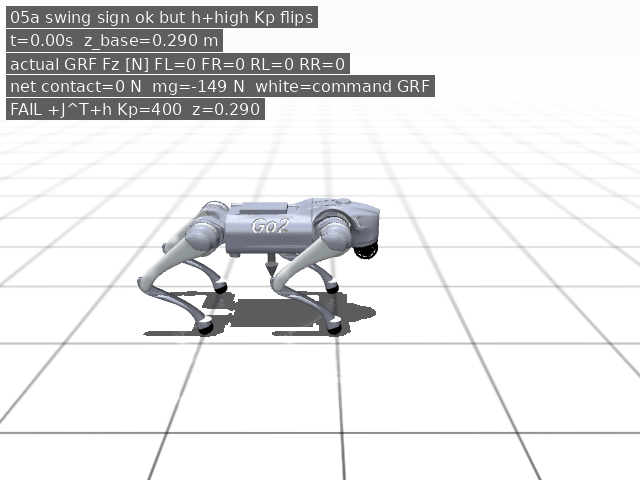

In [4]:
# --- このセルの意図 ---
# 試行 3: 符号は正しいが、遊脚に h を足し Kp=400。転倒する。GIF 05a を残す。

r3 = rollout(swing_sign=+1.0, add_h_swing=True, kp_s=400.0, kd_s=8.0, duty=0.90, step_h=0.025)
print("trial3 +J^T +h kp=400  hold", r3["hold"], "zmin", r3["zmin"], "rpy", r3["maxr"], "xy", r3["maxxy"])
print("  meas_air", r3["meas_air"], "swing_dz", r3["swing_dz"])
print("trial3 FAIL expected:", r3["hold"] < HOLD_S)

# --- 失敗 GIF ---
ctrl = {"phi": TROT_OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}

def tau_fail(pl):
    """内容: 試行 3 と同じ遊脚（h 付き、Kp=400、duty=0.9）。GIF 用。"""
    dt = pl.sim_dt
    if ctrl["lift"] is None:
        ctrl["lift"] = pl.feet_pos_world().copy()
    geoms = pl.foot_geom_ids()
    phi = (ctrl["phi"] + dt * FREQ) % 1.0
    c = (phi < 0.90).astype(float)
    ns = max(float(c.sum()), 1.0)
    z0 = float(pl.base_pos()[2]) if ctrl.get("z0") is None else ctrl["z0"]
    if "z0" not in ctrl:
        ctrl["z0"] = float(pl.base_pos()[2])
        z0 = ctrl["z0"]
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    fz_tot = pl.mass_kg * 9.81 + KP_Z * (z0 - z) - KD_Z * vz
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    cmd = np.zeros((4, 3))
    for i in range(4):
        if ctrl["prev"][i] > 0.5 and c[i] < 0.5:
            ctrl["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            F = np.array([0.0, 0.0, fz_tot / ns])
            cmd[i] = F
            tau[sl] = h[sl] - Jleg.T @ F
        else:
            s = float(np.clip((phi[i] - 0.90) / 0.10, 0.0, 1.0))
            p_d = ctrl["lift"][i].copy()
            p_d[2] = ctrl["lift"][i, 2] + 0.025 * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = 0.025 * np.pi * np.cos(np.pi * s) * (FREQ / 0.10)
            F_ee = 400.0 * (p_d - feet[i]) + 8.0 * (v_d - vel[i])
            tau[sl] = Jleg.T @ F_ee + h[sl]
    ctrl["phi"] = phi
    ctrl["prev"] = c
    ctrl["cmd"] = cmd
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant_f = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant_f.sim_dt))
path_fail = render_rollout_gif(
    plant_f,
    Path("assets/05a_swing_flip.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_fail,
    command_grf=lambda pl: ctrl["cmd"],
    extra_lines=lambda pl: [f"FAIL +J^T+h Kp=400  z={pl.base_pos()[2]:.3f}"],
    title="05a swing sign ok but h+high Kp flips",
)
print(path_fail.resolve(), path_fail.stat().st_size, "bytes")
display(Image(filename=str(path_fail)))


## 試行 4 — \( +J^{\top} \)、遊脚に \( h \) なし、短い遊脚（仮説 4）

接触が脚ごとに 0.15 s 以上切れ、かつ姿勢が 5 秒持つ組。これがこの段の合格である。


trial4  hold 6.712 zmin 0.28896701624959226 rpy 0.5822583134630158 xy 0.03671301953241108
  meas_air [0.258 0.262 0.246 0.254] cmd_air [0.28 0.28 0.28 0.28] swing_dz [0.00439758 0.00506585 0.00501726 0.00430567]
  pair_a 0.28 pair_b 0.28
05 PASS: in-place trot held 6.712 s with air [0.258 0.262 0.246 0.254]


/home/takuya/work/mpc_dog/notebook/assets/05b_inplace_trot.gif 1943079 bytes t 7.001999999999451


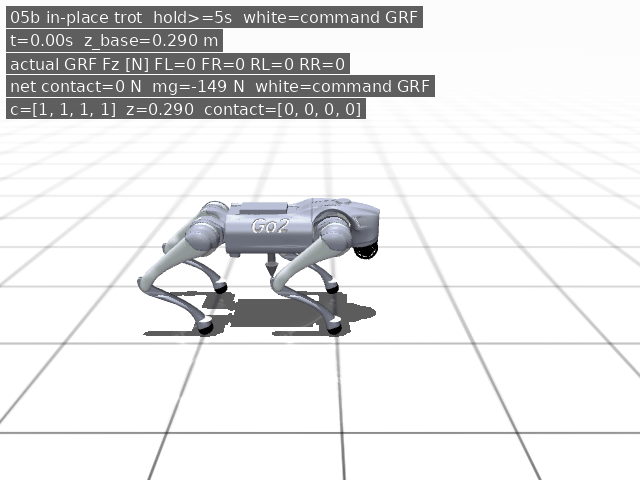

In [5]:
# --- このセルの意図 ---
# 試行 4: 合格組。遊脚は +J^T (Kp e)、h は足さない。duty=0.96 で overlap を残す。

r4 = rollout(swing_sign=+1.0, add_h_swing=False, kp_s=KP_SW, kd_s=KD_SW, duty=DUTY_OK, step_h=STEP_H)
print("trial4  hold", r4["hold"], "zmin", r4["zmin"], "rpy", r4["maxr"], "xy", r4["maxxy"])
print("  meas_air", r4["meas_air"], "cmd_air", r4["cmd_air"], "swing_dz", r4["swing_dz"])
print("  pair_a", r4["pair_a_s"], "pair_b", r4["pair_b_s"])
assert r4["hold"] >= HOLD_S, f"hold {r4['hold']:.3f}s < {HOLD_S}"
assert float(r4["meas_air"].min()) >= AIR_S, f"air {r4['meas_air']} < {AIR_S}"
assert r4["pair_a_s"] > 0.0 and r4["pair_b_s"] > 0.0
print("05 PASS: in-place trot held", r4["hold"], "s with air", r4["meas_air"])

# --- 成功 GIF ---
okc = {"phi": TROT_OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3)), "c": np.ones(4)}

def tau_ok(pl):
    """内容: 試行 4 と同じ。GIF の白矢印は立脚の指令 GRF。"""
    dt = pl.sim_dt
    if okc["lift"] is None:
        okc["lift"] = pl.feet_pos_world().copy()
        okc["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (okc["phi"] + dt * FREQ) % 1.0
    c = (phi < DUTY_OK).astype(float)
    ns = max(float(c.sum()), 1.0)
    z0 = okc["z0"]
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    fz_tot = pl.mass_kg * 9.81 + KP_Z * (z0 - z) - KD_Z * vz
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    cmd = np.zeros((4, 3))
    for i in range(4):
        if okc["prev"][i] > 0.5 and c[i] < 0.5:
            okc["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            F = np.array([0.0, 0.0, fz_tot / ns])
            cmd[i] = F
            tau[sl] = h[sl] - Jleg.T @ F
        else:
            s = float(np.clip((phi[i] - DUTY_OK) / max(1e-6, 1.0 - DUTY_OK), 0.0, 1.0))
            w = FREQ / max(1e-6, 1.0 - DUTY_OK)
            p_d = okc["lift"][i].copy()
            p_d[2] = okc["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            F_ee = KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i])
            tau[sl] = Jleg.T @ F_ee  # 内容: 遊脚に h を足さない
    okc["phi"] = phi
    okc["prev"] = c
    okc["c"] = c
    okc["cmd"] = cmd
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant.sim_dt))
path = render_rollout_gif(
    plant,
    Path("assets/05b_inplace_trot.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_ok,
    command_grf=lambda pl: okc["cmd"],
    extra_lines=lambda pl: [
        f"c={okc['c'].astype(int).tolist()}  z={pl.base_pos()[2]:.3f}  contact={pl.contact_on().astype(int).tolist()}"
    ],
    title="05b in-place trot  hold>=5s  white=command GRF",
)
print(path.resolve(), path.stat().st_size, "bytes", "t", float(plant.data.time))
display(Image(filename=str(path)))


## 分析

- 試行 1: 遊脚 PD が無いと軌道を追えない
- 試行 2: \( -J^{\top} \) は空中時間がほぼ 0。hold が長くても足踏みではない
- 試行 3: 符号は合っていても \( h \) と大きい \( K_p \) で転倒。GIF `05a` を残す
- 試行 4: 遊脚は \( +J^{\top} \) のみ、duty \(0.96\)。実測空中が指令に近く、連続 5 秒を満たした。GIF `05b`

EqualShare の 2 脚支持は細いので、この段の trot は overlap を長くした。PyMPC 既定の \(1.35\,\mathrm{Hz}/0.74\) は、脚力を予測最適化に差し替えてから戻す。

## 次の仮説

制御器は変えず、offset / freq / duty だけ変えるとペースやクロールになる。それが S4 である。
